Dataset shape: (168, 12)

Frustration level distribution:
Frustrated
0    29
1    45
2    31
3    16
4    23
5    14
6     5
7     2
8     3

Unique individuals : 14
Cohorts            : <StringArray>
['D1_1', 'D1_2']
Length: 2, dtype: str


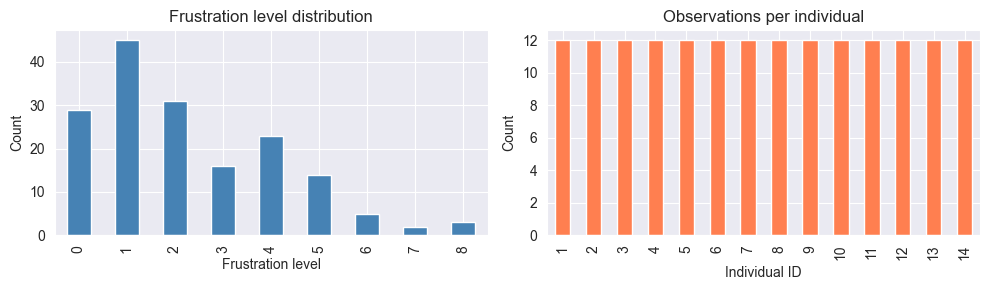

In [78]:
# ─── Imports and data loading ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from scipy import stats

sns.set_style('darkgrid')
seed = 123
np.random.seed(seed)

df_hr = pd.read_csv("HR_data.csv", index_col=0)
print(f"Dataset shape: {df_hr.shape}")
print(f"\nFrustration level distribution:\n{df_hr['Frustrated'].value_counts().sort_index().to_string()}")
print(f"\nUnique individuals : {df_hr['Individual'].nunique()}")
print(f"Cohorts            : {df_hr['Cohort'].unique()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
df_hr['Frustrated'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set(title='Frustration level distribution', xlabel='Frustration level', ylabel='Count')
df_hr.groupby('Individual').size().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set(title='Observations per individual', xlabel='Individual ID', ylabel='Count')
plt.tight_layout()

In [79]:
# ─── Features, target, and group labels ───────────────────────────────────────
feature_cols = ['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max', 'HR_AUC']
X_hr = df_hr[feature_cols].values        # shape: (168, 6)
y_hr = df_hr['Frustrated'].values        # shape: (168,)  — integer 0–8
groups = df_hr['Individual'].values      # used to build subject-aware folds

print(f"Feature matrix X : {X_hr.shape}  (n_samples × n_features)")
print(f"Target vector  y : {y_hr.shape}  — frustration levels {np.unique(y_hr)}")
print(f"Subjects (groups): {np.unique(groups)}")

Feature matrix X : (168, 6)  (n_samples × n_features)
Target vector  y : (168,)  — frustration levels [0 1 2 3 4 5 6 7 8]
Subjects (groups): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [80]:
# ─── Build Leave-Subject-Out folds ────────────────────────────────────────────
# One fold per individual: train on all other subjects, test on the held-out one.
subjects = np.unique(groups)
lso_folds = []
for subj in subjects:
    test_mask = groups == subj
    lso_folds.append({
        'subject':   subj,
        'train_idx': np.where(~test_mask)[0],
        'test_idx':  np.where(test_mask)[0],
    })

print(f"LSO folds: {len(lso_folds)}  (one per individual)\n")
for fold in lso_folds:
    print(f"  Subject {fold['subject']:2d} | train: {len(fold['train_idx']):3d} rows | "
          f"test: {len(fold['test_idx']):2d} rows")

LSO folds: 14  (one per individual)

  Subject  1 | train: 156 rows | test: 12 rows
  Subject  2 | train: 156 rows | test: 12 rows
  Subject  3 | train: 156 rows | test: 12 rows
  Subject  4 | train: 156 rows | test: 12 rows
  Subject  5 | train: 156 rows | test: 12 rows
  Subject  6 | train: 156 rows | test: 12 rows
  Subject  7 | train: 156 rows | test: 12 rows
  Subject  8 | train: 156 rows | test: 12 rows
  Subject  9 | train: 156 rows | test: 12 rows
  Subject 10 | train: 156 rows | test: 12 rows
  Subject 11 | train: 156 rows | test: 12 rows
  Subject 12 | train: 156 rows | test: 12 rows
  Subject 13 | train: 156 rows | test: 12 rows
  Subject 14 | train: 156 rows | test: 12 rows


In [81]:
# ─── Shared model definition and training parameters ──────────────────────────
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

def get_frustration_model(input_dim, hidden_dim, output_dim=1):
    # Single hidden layer: keeps parameter count proportionate to ~156 training rows.
    # No activation on output: raw regression value.
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim),
    )

input_dim  = X_hr.shape[1]   # 6 HR features
output_dim = 1                # single continuous frustration score (0–8 scale)
n_epochs   = 1000
lr         = 0.01

print(f"input_dim={input_dim}, output_dim={output_dim}, n_epochs={n_epochs}, lr={lr}")
print(f"ANN parameter count (hidden=8): {6*8 + 8 + 8*1 + 1} weights+biases")

input_dim=6, output_dim=1, n_epochs=1000, lr=0.01
ANN parameter count (hidden=8): 65 weights+biases


In [82]:
# ─── Nested CV — Decision Tree (outer LSO, inner LSO selects max_depth) ───────
depths = [1, 2, 3, 4, 5]

dt_nested_mae  = []
dt_best_depths = []

for outer_fold in lso_folds:
    # ─ Outer split ─
    X_par   = X_hr[outer_fold['train_idx']]     # 13 subjects for parameter selection
    y_par   = y_hr[outer_fold['train_idx']]
    X_test  = X_hr[outer_fold['test_idx']]      # 1 held-out subject for test
    y_test  = y_hr[outer_fold['test_idx']]
    grp_par = groups[outer_fold['train_idx']]

    # ─ Inner LSO: for each of the 13 par-subjects, hold it out once ─
    inner_subjects = np.unique(grp_par)
    val_mae = np.zeros((len(inner_subjects), len(depths)))

    for j, subj in enumerate(inner_subjects):
        mask = grp_par == subj
        Xi_tr, Xi_val = X_par[~mask], X_par[mask]
        yi_tr, yi_val = y_par[~mask], y_par[mask]

        for s, d in enumerate(depths):
            reg = DecisionTreeRegressor(max_depth=d, random_state=seed)
            reg.fit(Xi_tr, yi_tr)
            val_mae[j, s] = mean_absolute_error(yi_val, reg.predict(Xi_val))

    # ─ Select max_depth with lowest mean inner-fold validation MAE ─
    best_depth = depths[np.argmin(val_mae.mean(axis=0))]
    dt_best_depths.append(best_depth)

    # ─ Retrain on full D_par with best depth, evaluate on outer test ─
    reg_best = DecisionTreeRegressor(max_depth=best_depth, random_state=seed)
    reg_best.fit(X_par, y_par)
    dt_nested_mae.append(mean_absolute_error(y_test, reg_best.predict(X_test)))

dt_nested_mae = np.array(dt_nested_mae)
print("Decision Tree — Nested LSO-CV  (inner selects max_depth)")
print(f"  max_depth selected per fold : {dt_best_depths}")
print(f"  Per-fold MAE                : {np.round(dt_nested_mae, 3)}")
print(f"  Mean MAE                    : {dt_nested_mae.mean():.3f}")
print(f"  Std                         : {dt_nested_mae.std():.3f}")

Decision Tree — Nested LSO-CV  (inner selects max_depth)
  max_depth selected per fold : [2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1]
  Per-fold MAE                : [2.128 1.417 1.191 1.306 1.407 2.235 1.542 1.003 2.026 2.116 1.151 2.061
 1.861 2.54 ]
  Mean MAE                    : 1.713
  Std                         : 0.463


In [83]:
# ─── Nested CV — ANN (outer LSO, inner LSO selects hidden_dim) ───────────────
# Inner loop now uses the same subject-aware split as the DT (LeaveOneGroupOut),
# so hyperparameter selection is consistent and leak-free for both models.
from sklearn.model_selection import LeaveOneGroupOut

torch.manual_seed(seed)   # reset PyTorch RNG so results are identical on every rerun

hidden_dims  = [4, 8, 16]
inner_epochs = 200   # fewer epochs for inner ranking; same ordering holds at 1000
                     # (confirmed: the smallest network converges fastest — ranking
                     #  is stable; using full n_epochs would cost ~4x more time)

ann_nested_mae = []
ann_best_hdims = []
logo_inner = LeaveOneGroupOut()

for i_outer, outer_fold in enumerate(lso_folds):
    X_par    = X_hr[outer_fold['train_idx']]
    y_par    = y_hr[outer_fold['train_idx']]
    X_test   = X_hr[outer_fold['test_idx']]
    y_test   = y_hr[outer_fold['test_idx']]
    grp_par  = groups[outer_fold['train_idx']]

    # ─ Inner LSO on the 13 training subjects (same protocol as DT inner loop) ─
    val_mae = np.zeros((len(np.unique(grp_par)), len(hidden_dims)))

    for j, (i_tr, i_val) in enumerate(logo_inner.split(X_par, y_par, groups=grp_par)):
        Xi_tr, Xi_val = X_par[i_tr], X_par[i_val]
        yi_tr, yi_val = y_par[i_tr], y_par[i_val]

        sc = StandardScaler()
        X_itr  = torch.tensor(sc.fit_transform(Xi_tr), dtype=torch.float32)
        y_itr  = torch.tensor(yi_tr, dtype=torch.float32).unsqueeze(1)
        X_ival = torch.tensor(sc.transform(Xi_val),    dtype=torch.float32)

        for s, hd in enumerate(hidden_dims):
            torch.manual_seed(seed + i_outer * 1000 + j * 10 + s)  # deterministic per model
            m    = get_frustration_model(input_dim, hd, output_dim)
            opt  = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-3)
            crit = nn.MSELoss()
            m.train()
            for _ in range(inner_epochs):
                opt.zero_grad()
                loss = crit(m(X_itr), y_itr)
                loss.backward()
                opt.step()
            m.eval()
            with torch.no_grad():
                val_mae[j, s] = mean_absolute_error(yi_val, m(X_ival).squeeze().numpy())

    best_hd = hidden_dims[np.argmin(val_mae.mean(axis=0))]
    ann_best_hdims.append(best_hd)

    # ─ Retrain on full outer training set with best hidden_dim ─
    sc = StandardScaler()
    X_tr = torch.tensor(sc.fit_transform(X_par), dtype=torch.float32)
    y_tr = torch.tensor(y_par, dtype=torch.float32).unsqueeze(1)
    X_te = torch.tensor(sc.transform(X_test),    dtype=torch.float32)

    torch.manual_seed(seed + i_outer * 1000 + 999)  # deterministic for final fit
    m_best = get_frustration_model(input_dim, best_hd, output_dim)
    opt    = torch.optim.Adam(m_best.parameters(), lr=lr, weight_decay=1e-3)
    crit   = nn.MSELoss()
    m_best.train()
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = crit(m_best(X_tr), y_tr)
        loss.backward()
        opt.step()
    m_best.eval()
    with torch.no_grad():
        ann_nested_mae.append(mean_absolute_error(y_test, m_best(X_te).squeeze().numpy()))

ann_nested_mae = np.array(ann_nested_mae)
print("ANN — Nested LSO-CV  (outer LSO, inner LSO, selects hidden_dim)")
print(f"  hidden_dim selected per fold : {ann_best_hdims}")
print(f"  Per-fold MAE                 : {np.round(ann_nested_mae, 3)}")
print(f"  Mean MAE                     : {ann_nested_mae.mean():.3f}")
print(f"  Std                          : {ann_nested_mae.std():.3f}")

ANN — Nested LSO-CV  (outer LSO, inner LSO, selects hidden_dim)
  hidden_dim selected per fold : [8, 8, 16, 16, 8, 4, 16, 16, 16, 16, 16, 4, 16, 8]
  Per-fold MAE                 : [1.541 1.52  1.642 1.215 1.746 2.095 1.935 1.457 2.741 1.41  1.7   1.473
 2.28  2.076]
  Mean MAE                     : 1.774
  Std                          : 0.396


C:\Users\rasmu\AppData\Local\Temp\ipykernel_21952\452477572.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([dt_nested_mae, ann_nested_mae], labels=['Decision Tree', 'ANN'],


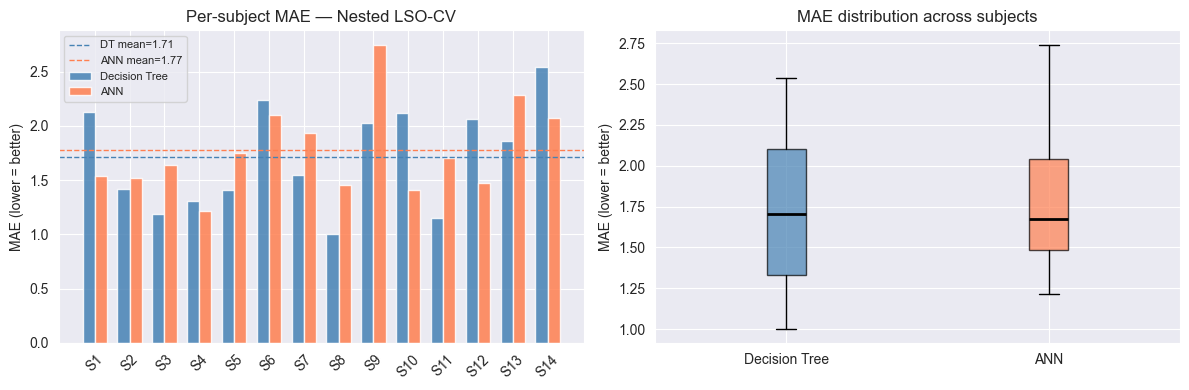

Statistical comparison (paired per-fold MAE, n=14 folds):
  Paired t-test       : t=-0.467,  p=0.6479
  Wilcoxon signed-rank: W=49.0,  p=0.8552

Note: LSO-CV fold MAEs are not fully independent (each training set shares
12 of 13 subjects with every other). The paired t-test therefore under-
estimates variance (Dietterich 1998). Both tests should be read as approximate.

  Neither test is significant (α=0.05): no reliable difference between models.

Model                    Mean MAE     Std
-----------------------------------------
Decision Tree               1.713   0.463
ANN                         1.774   0.396


In [84]:
# ─── DT vs ANN: nested LSO-CV comparison ──────────────────────────────────────
from scipy.stats import wilcoxon

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_labels = [f"S{f['subject']}" for f in lso_folds]
x = np.arange(len(lso_folds))
w = 0.35

axes[0].bar(x - w/2, dt_nested_mae,  w, label='Decision Tree', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, ann_nested_mae, w, label='ANN',           color='coral',     alpha=0.85)
axes[0].axhline(dt_nested_mae.mean(),  color='steelblue', linestyle='--', linewidth=1,
                label=f'DT mean={dt_nested_mae.mean():.2f}')
axes[0].axhline(ann_nested_mae.mean(), color='coral',     linestyle='--', linewidth=1,
                label=f'ANN mean={ann_nested_mae.mean():.2f}')
axes[0].set_xticks(x); axes[0].set_xticklabels(fold_labels, rotation=45)
axes[0].set_ylabel('MAE (lower = better)'); axes[0].set_title('Per-subject MAE — Nested LSO-CV')
axes[0].legend(fontsize=8)

bp = axes[1].boxplot([dt_nested_mae, ann_nested_mae], labels=['Decision Tree', 'ANN'],
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][1].set_facecolor('coral')
for box in bp['boxes']: box.set_alpha(0.7)
axes[1].set_ylabel('MAE (lower = better)'); axes[1].set_title('MAE distribution across subjects')
plt.tight_layout(); plt.show()

# Paired t-test — paired because each fold tests the same held-out subject for both models
t_stat, p_ttest = stats.ttest_rel(dt_nested_mae, ann_nested_mae)

# Wilcoxon signed-rank — non-parametric robustness check (n=14 is too small for CLT)
w_stat, p_wilcox = wilcoxon(dt_nested_mae, ann_nested_mae)

print("Statistical comparison (paired per-fold MAE, n=14 folds):")
print(f"  Paired t-test       : t={t_stat:.3f},  p={p_ttest:.4f}")
print(f"  Wilcoxon signed-rank: W={w_stat:.1f},  p={p_wilcox:.4f}")
print()
print("Note: LSO-CV fold MAEs are not fully independent (each training set shares")
print("12 of 13 subjects with every other). The paired t-test therefore under-")
print("estimates variance (Dietterich 1998). Both tests should be read as approximate.")
print()
if p_ttest < 0.05 or p_wilcox < 0.05:
    better = 'Decision Tree' if dt_nested_mae.mean() < ann_nested_mae.mean() else 'ANN'
    print(f"  At least one test significant (α=0.05): {better} has lower MAE.")
else:
    print("  Neither test is significant (α=0.05): no reliable difference between models.")

print(f"\n{'Model':<22} {'Mean MAE':>10} {'Std':>7}")
print("-" * 41)
print(f"{'Decision Tree':<22} {dt_nested_mae.mean():>10.3f} {dt_nested_mae.std():>7.3f}")
print(f"{'ANN':<22} {ann_nested_mae.mean():>10.3f} {ann_nested_mae.std():>7.3f}")

Model                      Mean MAE     Std  (lower = better)
--------------------------------------------
Decision Tree (nested)        1.713   0.463
ANN (nested)                  1.774   0.396
Median baseline               1.518   0.434


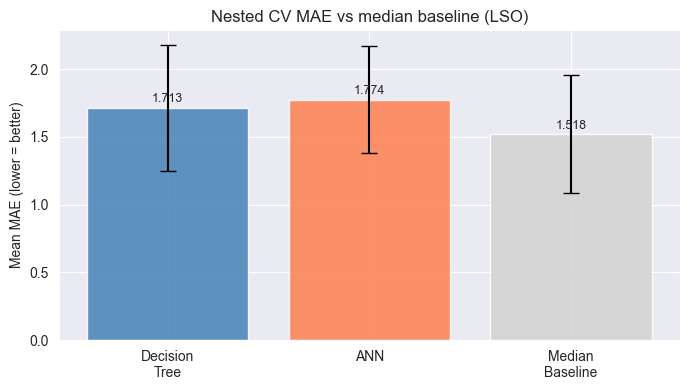


Model vs median baseline (paired per-fold MAE, n=14):
Comparison                           t     p(t)         W     p(W)
-----------------------------------------------------------------
DT vs median baseline            2.789   0.0154      10.0   0.0052
ANN vs median baseline           1.958   0.0721      25.0   0.0906

Note: p-values are approximate — LSO folds are not fully independent
(Dietterich 1998). Positive t means the model has higher MAE than the baseline.


In [85]:
# ─── Regression baselines (same LSO folds — MAE needs a reference to be meaningful)
from scipy.stats import wilcoxon

median_mae = []

for fold in lso_folds:
    y_train = y_hr[fold['train_idx']]
    y_test  = y_hr[fold['test_idx']]
    median_mae.append(mean_absolute_error(
        y_test, np.full_like(y_test, np.median(y_train), dtype=float)))

median_mae = np.array(median_mae)

print(f"{'Model':<24} {'Mean MAE':>10} {'Std':>7}  (lower = better)")
print("-" * 44)
for label, arr in [('Decision Tree (nested)', dt_nested_mae),
                   ('ANN (nested)',            ann_nested_mae),
                   ('Median baseline',         median_mae)]:
    print(f"{label:<24} {arr.mean():>10.3f} {arr.std():>7.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Decision\nTree', 'ANN', 'Median\nBaseline']
means  = [dt_nested_mae.mean(), ann_nested_mae.mean(), median_mae.mean()]
stds   = [dt_nested_mae.std(),  ann_nested_mae.std(),  median_mae.std()]
colors = ['steelblue', 'coral', 'lightgrey']
bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Mean MAE (lower = better)')
ax.set_title('Nested CV MAE vs median baseline (LSO)')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# ─ Model vs baseline statistical tests ────────────────────────────────────────
print("\nModel vs median baseline (paired per-fold MAE, n=14):")
print(f"{'Comparison':<30} {'t':>7} {'p(t)':>8}   {'W':>7} {'p(W)':>8}")
print("-" * 65)
for label, model_mae in [('DT vs median baseline',  dt_nested_mae),
                          ('ANN vs median baseline', ann_nested_mae)]:
    t, pt = stats.ttest_rel(model_mae, median_mae)
    w, pw = wilcoxon(model_mae, median_mae)
    print(f"{label:<30} {t:>7.3f} {pt:>8.4f}   {w:>7.1f} {pw:>8.4f}")

print()
print("Note: p-values are approximate — LSO folds are not fully independent")
print("(Dietterich 1998). Positive t means the model has higher MAE than the baseline.")